<a href="https://colab.research.google.com/github/aidenmurphy-a11y/csci210_proj3/blob/main/2c_regression_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2c: Regression Fundamentals

Welcome to your first graded modeling lab. This builds directly on the Python, pandas, and
plotting groundwork from *1a (Getting Started)*. Now we point those tools at a real prediction
problem. From here on the level of hand-holding starts going *down* on purpose: you'll do more
thinking (and more reading of documentation) so you're ready for real data-science work.

Two rules guide this whole notebook:

1. We never call a function we couldn't have written ourselves. Today you'll build `predict`,
   `RMSE`, and `R^2` from scratch before you're allowed the one-liner.
2. Every claim a model makes, we check. We run the model first, then open it up and confirm where
   each number came from.

The biology behind it: field biologists at Palmer Station measured hundreds of Antarctic
penguins by hand, recording bills, flippers, and body mass across three islands. Measuring a flipper
means catching a penguin; measuring a bill is easy. So, from a couple of easy measurements, can we
predict a hard one, and which measurements carry the signal?


### How hidden checks work

Most autograded points are in the public test cells that you can run and read. A smaller hidden
check may recompute your result from the submitted objects or repeat the method on a fresh split.
It is there to catch hardcoded answers, not to require one exact coding style.

To protect your hidden-check points:

- use the required variable names and the requested source frame, split, metric, and random seed;
- preserve pandas indices and column labels unless the instructions say to reset them;
- derive predictions, scores, and tables in code instead of typing expected values;
- return the requested values as a normal one-dimensional iterable when several container types
  make sense; and
- run every public test before submitting, then use the specific Gradescope hint if a hidden check
  still fails.


## On tap

- **Question 1:** reproduce `.predict` yourself: compute every prediction as `X @ coef_ + intercept_`.
- **Question 2:** build the model's report card (`RMSE` and `R^2`) from scratch and watch it match sklearn.
- **Question 3:** make a real decision: does telling the model the *species* improve the prediction?
- **Question 4:** turn the same linear model into a **classifier** (logistic regression) and read its coefficients.
- **Challenge:** engineer a feature set that beats a baseline on a held-out split you can't see.

> **Test guidance:** Public tests carry most autograded points overall, so run this task's public test before submitting. Its smaller hidden check recomputes the result from the required objects, so derive values in code and preserve the requested labels, split, metric, and seed.

## Learning Objectives

By the end of this assignment you will be able to:

1. **Compute** a linear model's predictions by hand from its `coef_` and `intercept_`, and match `.predict`.
2. **Implement** `RMSE` and `R^2` from scratch with NumPy and explain what each number tells a domain expert.
3. **Decide** whether a categorical feature improves a regression, and **justify** the result from the fitted coefficients.
4. **Build** a logistic-regression classifier and **interpret** the sign and scale of its coefficients.
5. **Select** a feature set that beats a baseline on a held-out split, and **evaluate** it without leaking the target.

## How to read this notebook

Work through the callouts as you go; they appear throughout the lab and each one means the same
thing every time:

> **Note:** a fact worth pinning down.

> **Tip:** a shortcut or good habit.

> **Warning:** a common trap.

> **Analogy:** the idea in everyday terms.

> **Jargon, term:** a one-line definition of a word we just used.

> **Key points:** a short recap that closes a section.

> **Predict, then check:** write down what you expect *before* you run the reveal cell. There is always a place to record your guess.

> **Reflect:** a short written answer (graded ones are scored on *content*, not length).

> **Go deeper:** optional links: *what it is, why click, ~how long*. They are extra, so you can finish the lab without them.

> **Playground (optional, not graded):** a cell to poke at. It only touches throwaway `_`-named variables, so nothing you do there can change your grade.

The graded cells follow one rhythm: a **worked demo** you run, a **prediction** you record, then **your turn** to write a small variation. Names matter: the autograder looks for the exact variable names in each task.

---


In [ ]:
# Imports and global settings
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             confusion_matrix, accuracy_score)

# House theme for every plot (legible when projected; colorblind-safe palette).
sns.set_theme(style="whitegrid", palette="colorblind", context="notebook", font_scale=1.2)
plt.rcParams["figure.figsize"] = (10, 6)

# Seed 42 because it's the answer to life, the universe, and everything, and a fixed seed makes
# every train/test split repeatable, which makes results easy to debug and reproduce.
RANDOM_STATE = 42
ALT_RANDOM_STATE = 7   # used ONLY inside hidden grading recomputes (a "fresh split" you can't see)

## The dataset: Palmer Penguins

We work with the Palmer Penguins. A quick clean: drop rows with missing values, and drop the
`year` column. There could be systematic differences between collection years, and training on them
would make the model worse on new data, not better.

> **Jargon, features / target:** the input columns are the **features** (the matrix `X`); the one
> thing we predict is the **target** (`y`). Today most features are penguin measurements and the
> target is one we hold out.

> **Warning:** never put the target back into `X`. If the answer is already in the input, the model
> "scores" perfectly and learns nothing useful, a beginner trap called *target leakage*.

> **Go deeper:** [The Palmer Penguins dataset](https://allisonhorst.github.io/palmerpenguins/):
> *what it is:* the friendly, well-documented alternative to the classic iris dataset, *why click:*
> a one-page tour of the three species and the measurements, *~3 min.*

In [8]:
penguins = pd.read_csv('penguins-1.csv')
penguins = penguins.dropna()
penguins = penguins.drop(columns=['year'])

print(f"Dataset shape: {penguins.shape}")
display(penguins.head())

Dataset shape: (333, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male


### First look: is prediction even possible?

Before modeling anything, look at the data. The single most useful plot for a regression is the
scatter of a candidate feature against the target.

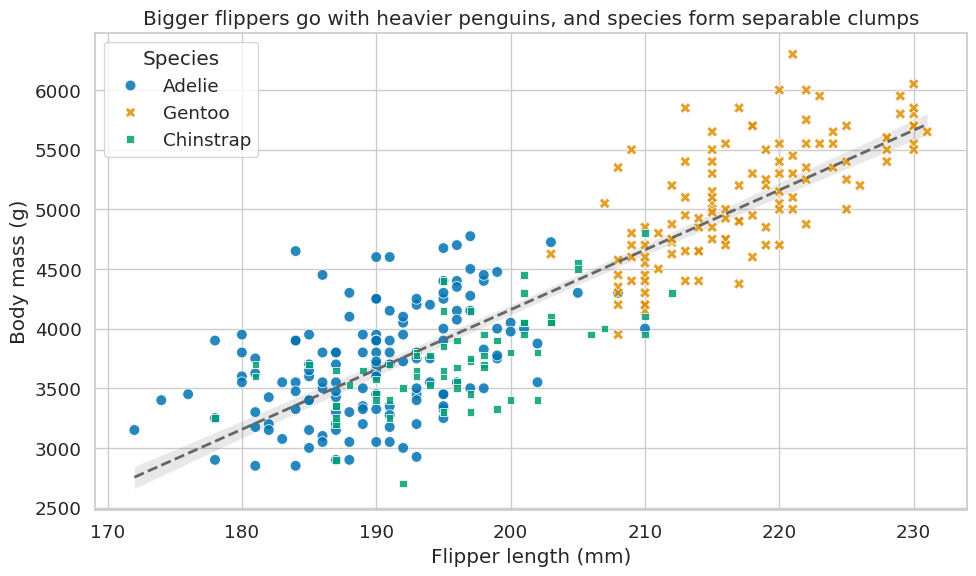

In [9]:
# A free, fully-worked EDA plot. (You never write plotting code for credit in this course.)
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(data=penguins, x='flipper_length_mm', y='body_mass_g',
            scatter=False, color='0.4', line_kws={'lw': 2, 'ls': '--'}, ax=ax)
# Double-encode species with marker style too, so the figure survives grayscale (colorblind-safe).
sns.scatterplot(data=penguins, x='flipper_length_mm', y='body_mass_g',
                hue='species', style='species', s=60, alpha=0.85, ax=ax)
ax.set_title("Bigger flippers go with heavier penguins, and species form separable clumps")
ax.set_xlabel("Flipper length (mm)")
ax.set_ylabel("Body mass (g)")
ax.legend(title="Species")
plt.tight_layout()
plt.show()

Each point is one penguin, plotted by flipper length (x) and body mass (y) and colored by species;
the dashed line is the overall linear trend. The points hug a tight diagonal (bigger flippers go
with heavier birds), and the three species sit in near-separable colored groups.

That diagonal is the signal a regression will use, so prediction is possible here. Keep the groups
in mind: they come back when we add species to a regression, and again when we classify species
directly.


### The win: predict a flipper with a handful of lines

Here is the whole supervised loop, written out and run, so you can see the result before we explain
how it works. We'll predict `flipper_length_mm` from two easy measurements.


On penguins it had never seen, we predicted flipper length within ~5.9 mm (flippers run ~170-230 mm).


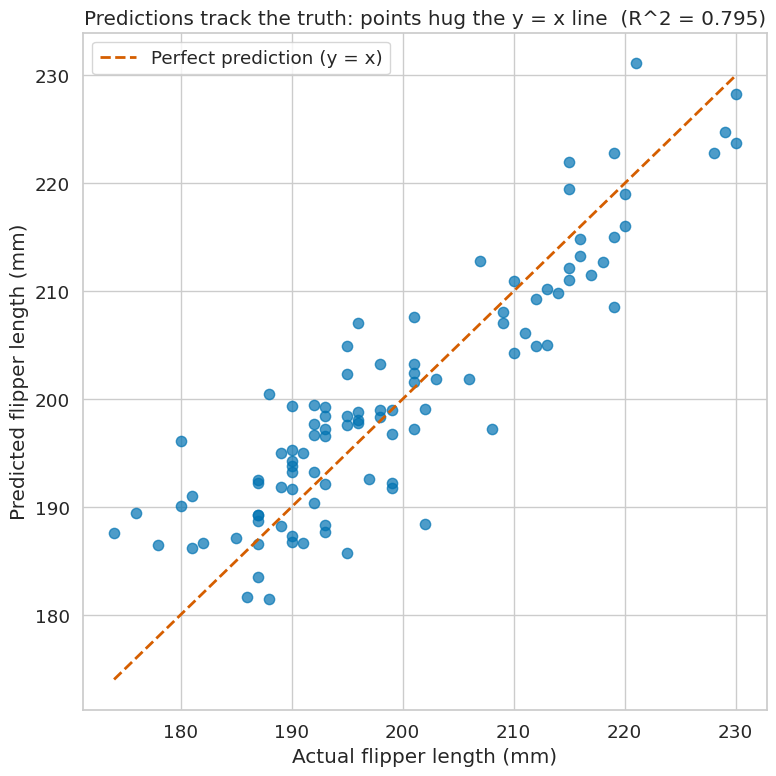

In [10]:
X = penguins[['bill_length_mm', 'body_mass_g']]
y = penguins['flipper_length_mm']
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE)

demo = LinearRegression().fit(Xtr, ytr)
preds = demo.predict(Xte)

rmse_demo = np.sqrt(mean_squared_error(yte, preds))
print(f"On penguins it had never seen, we predicted flipper length within "
      f"~{rmse_demo:.1f} mm (flippers run ~170-230 mm).")

# The classic regression diagnostic: predicted vs. actual, with the y=x "perfect prediction" line.
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(yte, preds, alpha=0.7, s=55, marker='o')
lo, hi = yte.min(), yte.max()
ax.plot([lo, hi], [lo, hi], 'r--', lw=2, label='Perfect prediction (y = x)')
ax.set_xlabel("Actual flipper length (mm)")
ax.set_ylabel("Predicted flipper length (mm)")
ax.set_title(f"Predictions track the truth: points hug the y = x line  (R^2 = {r2_score(yte, preds):.3f})")
ax.legend()
plt.tight_layout()
plt.show()

Every test penguin is plotted as (actual flipper length, predicted flipper length), and the red
dashed line marks a perfect prediction. The cloud sits tightly along that line, so the model is
rarely far off, and `R^2` is high.

A handful of lines already predict a hard-to-measure trait from two easy ones. The rest of this lab
takes that `.fit` / `.predict` apart so you know what it computed.


### What just happened (the roadmap)

That `.fit` / `.predict` did a lot of work in a few lines. Underneath, three numbers run the show:
the prediction `y_hat`, the error `RMSE`, and the score `R^2`. The rest of this lab does not take
them on faith.

In **Questions 1 and 2** you rebuild all three from scratch and watch them match sklearn to the
decimal. After that the hand-holding drops: you make a real feature decision (Q3), build a logistic
classifier on the same linear score (Q4), and engineer your way past a hidden baseline (the Challenge).

---


## Question 1: Predictions by hand: `y_hat = X @ coef_ + intercept_`  (3 pts)

**The question this answers:** `demo.predict(X)` returned an array of numbers. *Where did those
numbers come from?* Once you can reproduce `.predict` yourself, the model stops being a black box.

**The concept, just in time.** A linear model is multiply-and-add. For one penguin with features
`x` it predicts

> `y_hat = b + (coef_0 * x_0) + (coef_1 * x_1) + ...`

and for the whole matrix at once, in linear-algebra form,

> `y_hat = X @ coef_ + intercept_`

sklearn stashes the learned pieces on the fitted model:
- `model.coef_`: one weight per feature (here, length-2),
- `model.intercept_`: the scalar `b`.

For our fitted model that is `y_hat = 124.10 + 0.506*bill + 0.013*mass`.

> **Go deeper:** [sklearn `LinearRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html):
> *what it is:* the official API for the model we just fit, *why click:* see where `coef_`
> and `intercept_` come from, *~4 min.*

In [11]:
# Worked demo: predict ONE penguin by hand, and show it matches sklearn.
print("coef_      :", demo.coef_)
print("intercept_ :", demo.intercept_)

first = Xte.iloc[0].values          # [bill_length_mm, body_mass_g] of the first test penguin
by_hand_one = demo.intercept_ + demo.coef_[0] * first[0] + demo.coef_[1] * first[1]

print(f"\nFirst test penguin features: bill={first[0]:.1f} mm, mass={first[1]:.0f} g")
print(f"By hand : y_hat = {demo.intercept_:.2f} + {demo.coef_[0]:.3f}*{first[0]:.1f} "
      f"+ {demo.coef_[1]:.3f}*{first[1]:.0f}  =  {by_hand_one:.3f}")
print(f"sklearn : demo.predict(Xte)[0]                                   =  {demo.predict(Xte)[0]:.3f}")
print("\nThat is ONE penguin, computed one scalar at a time. Your turn is to do ALL of them at once")
print("with a single matrix expression. The shapes below tell you how the pieces must fit together.")
print(f"   Xte.values  shape {Xte.values.shape}   (one row per test penguin, one column per feature)")
print(f"   demo.coef_  shape {demo.coef_.shape}   (one weight per feature)")
print(f"   demo.intercept_ is a scalar: {demo.intercept_:.2f}")
print("Question for you: what single operation turns an (n, 2) matrix and a (2,) weight vector into")
print("an (n,) vector of predictions, and what do you add afterward? Predict the shapes, then write it.")

coef_      : [0.50639188 0.01303386]
intercept_ : 124.09827803016479

First test penguin features: bill=39.5 mm, mass=3250 g
By hand : y_hat = 124.10 + 0.506*39.5 + 0.013*3250  =  186.461
sklearn : demo.predict(Xte)[0]                                   =  186.461

That is ONE penguin, computed one scalar at a time. Your turn is to do ALL of them at once
with a single matrix expression. The shapes below tell you how the pieces must fit together.
   Xte.values  shape (100, 2)   (one row per test penguin, one column per feature)
   demo.coef_  shape (2,)   (one weight per feature)
   demo.intercept_ is a scalar: 124.10
Question for you: what single operation turns an (n, 2) matrix and a (2,) weight vector into
an (n,) vector of predictions, and what do you add afterward? Predict the shapes, then write it.


> **Predict, then check:** `Xte` has shape `(n, 2)` and `coef_` has shape `(2,)`.
>
> - What shape comes out of `Xte.values @ coef_`?
> - What do you add next, and what is the shape of the final result?
>
> Record your guess in the cell below, *then* write the one-liner.

In [12]:
# Predict, then check (not graded). Record your guess as a string, then run the cells below.
predict_q1 = "(2.5,)"   # e.g. "X @ coef_ gives (n,); add the scalar intercept; final shape (n,)"

**Goal:** compute every prediction yourself with a single matrix expression. No `.predict`, no loop.

**Steps:**
1. Pull the learned pieces off the fitted model: `demo.coef_` (the weights) and `demo.intercept_` (the bias).
2. Turn the feature frame into a NumPy array with **`Xte.values`**: keep numeric work in arrays, not pandas objects.
3. Combine them with one matrix operation so that an `(n, 2)` matrix and a `(2,)` weight vector give an
   `(n,)` vector of predictions, then add the scalar bias. (The demo above printed those exact shapes.)

You assemble the expression; there is no code skeleton this time. If the shape comes out wrong, re-read
the shapes the demo printed.

In [53]:
# y_pred_manual: 1-D NumPy array of length len(yte), the predictions computed by hand
y_pred_manual = Xte.values @ demo.coef_ + demo.intercept_

# YOUR CODE HERE



In [54]:
# Self-check (free): your hand-built predictions vs. sklearn's.
if y_pred_manual is not None:
    print("By hand :", np.round(y_pred_manual[:3], 3))
    print("sklearn :", np.round(demo.predict(Xte)[:3], 3))
    print("Match all?", np.allclose(y_pred_manual, demo.predict(Xte)))
    print("\nOne penguin by hand became all of them with one line, and it matches sklearn.")
else:
    print("Fill in y_pred_manual above, then run this cell.")


By hand : [186.461 197.773 197.553]
sklearn : [186.461 197.773 197.553]
Match all? True

One penguin by hand became all of them with one line, and it matches sklearn.


In [55]:
# Visible sanity check: the deliverable exists with the right shape and matches sklearn.
# (1 of this question's 3 points is this visible check; the other 2 are a hidden recompute.)
assert y_pred_manual is not None, "y_pred_manual is still None: compute X @ coef_ + intercept_."
assert np.asarray(y_pred_manual).shape == (len(yte),), \
    f"y_pred_manual should have shape ({len(yte)},), got {np.asarray(y_pred_manual).shape}"
assert np.allclose(y_pred_manual, demo.predict(Xte)), \
    "Manual predictions must match demo.predict(Xte)."

> **Reflect:** look at the two coefficients. Which feature moved this penguin's prediction more,
> and was it the one with the *bigger* coefficient? Hold that thought; it comes back when we interpret
> coefficients in Question 4.

> **Key points:**
> - `.predict` is nothing but `X @ coef_ + intercept_`: multiply each feature by its weight and add the bias.
> - The learned pieces live on the fitted model as `coef_` (one per feature) and `intercept_` (a scalar).
> - You reproduced sklearn's output to the decimal, so the model is no longer a black box.

---

## Question 2: RMSE and R^2 from scratch  (3 pts)

**The question this answers:** we have predictions. *How wrong are they, in one honest number, and
how do we know whether that number is any good?*

**The concept, just in time.** Three error families, smallest to most-used:

- **MAE:** `mean(|y - y_hat|)`. The gentle cousin: average miss in the original units.
- **RMSE:** `sqrt(mean((y - y_hat)^2))`. Squares errors before averaging, so big misses hurt more;
  the square root puts it back in the original units (mm here).
- **R^2:** `1 - SS_res / SS_tot`, where `SS_res = sum((y - y_hat)^2)` and
  `SS_tot = sum((y - mean(y))^2)`.

> **Analogy:** `R^2` is a grade *on a curve*. It compares your model's errors to the dumbest model
> there is, always guessing the mean. `R^2 = 0` means *no better than that guess*; `R^2 = 1` means
> *perfect*; negative means *worse than guessing the mean*.

> **Go deeper:** [sklearn regression metrics](https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics):
> *what it is:* the official definitions of MAE, MSE, and `r2_score`, *why click:* confirm your
> from-scratch formulas match the library's, *~5 min.*

In [17]:
# Worked demo: MAE by hand (we do this one for you; you'll do the squared ones).
if y_pred_manual is not None:
    mae = np.mean(np.abs(yte.values - y_pred_manual))
    print(f"MAE by hand : {mae:.4f}")
    print(f"sklearn     : {mean_absolute_error(yte, y_pred_manual):.4f}")
    print("Same number. RMSE and R^2 follow the exact same pattern. Your turn.")
else:
    print("Fill in y_pred_manual in Question 1 first, then run this cell.")

MAE by hand : 4.8354
sklearn     : 4.8354
Same number. RMSE and R^2 follow the exact same pattern. Your turn.


> **Predict, then check:** RMSE squares the errors before averaging, then takes a square root.
> Will RMSE come out **larger or smaller** than the MAE you just saw, and *why*? (Think about what
> squaring does to a few big misses.) Record your guess below.

In [18]:
# Predict, then check (not graded). Record your guess as a string, then run the cells below.
predict_q2 = "RSME = MAE"   # e.g. "RMSE >= MAE, because squaring punishes the few large misses"

**Goal:** compute RMSE and R^2 **from scratch** with NumPy only. No `mean_squared_error`, no
`r2_score`.

**Steps:**
1. Form the error vector `err = yte.values - y_pred_manual`.
2. `rmse_manual = sqrt(mean(err^2))`.
3. `ss_res = sum(err^2)`; `ss_tot = sum((yte - mean(yte))^2)`; `r2_manual = 1 - ss_res/ss_tot`.

In [19]:
# rmse_manual: float, root-mean-squared error computed by hand
# r2_manual:   float, coefficient of determination computed by hand

# YOUR CODE HERE
err = yte.values - y_pred_manual
rmse_manual = np.sqrt(np.mean(err**2))

ss_res = np.sum(err**2)
ss_tot = np.sum((yte - np.mean(yte))**2)
r2_manual = 1 - ss_res / ss_tot

In [20]:
# Self-check (free): your from-scratch metrics vs. sklearn.
if rmse_manual is not None and r2_manual is not None:
    print(f"RMSE  by hand: {rmse_manual:.4f}   sklearn: {np.sqrt(mean_squared_error(yte, y_pred_manual)):.4f}   "
          f"match? {np.isclose(rmse_manual, np.sqrt(mean_squared_error(yte, y_pred_manual)))}")
    print(f"R^2   by hand: {r2_manual:.4f}   sklearn: {r2_score(yte, y_pred_manual):.4f}   "
          f"match? {np.isclose(r2_manual, r2_score(yte, y_pred_manual))}")
    print("\nYou just built the model's entire report card from scratch, and it matches sklearn to the decimal.")
else:
    print("Fill in rmse_manual and r2_manual above, then run this cell.")

RMSE  by hand: 5.8790   sklearn: 5.8790   match? True
R^2   by hand: 0.7951   sklearn: 0.7951   match? True

You just built the model's entire report card from scratch, and it matches sklearn to the decimal.


In [21]:
# Visible sanity check: both metrics exist and match sklearn.
# (1 of this question's 3 points is this visible check; the other 2 are a hidden recompute.)
assert rmse_manual is not None and r2_manual is not None, "Compute both rmse_manual and r2_manual."
assert np.isclose(rmse_manual, np.sqrt(mean_squared_error(yte, y_pred_manual))), \
    "rmse_manual must match sklearn's mean_squared_error."
assert np.isclose(r2_manual, r2_score(yte, y_pred_manual)), \
    "r2_manual must match sklearn's r2_score."

> **Reflect:** your R^2 here is about 0.80, and flippers span about 170 to 230 mm. In one sentence:
> what does an R^2 of 0.80 tell a biologist, and is being off by about 5.9 mm good?

> **Tip, abstraction step-up:** the pieces are built. From here on you may call `model.predict`,
> `mean_squared_error`, and `r2_score` directly, now that you know what each number means.

> **Key points:**
> - RMSE and MAE both live in the target's units; RMSE is `>=` MAE because squaring punishes big misses.
> - `R^2` rescales errors against the mean-only baseline: 1 perfect, 0 no better than the mean, negative worse.
> - Your from-scratch numbers matched sklearn to the decimal, so you can trust the library now.

---


## Question 3: Does species help? A real decision  (2 + 2 = 4 pts)

**The question this answers:** remember those color-coded groups in the opening scatter? Our model only
sees two numbers (bill, mass), but these are *three different species*. Can telling the model the
species improve the flipper prediction, or is species just baggage already captured by size?

**The concept, just in time.** Models do math on numbers, not on the string `"Gentoo"`. **One-hot
encoding** turns a categorical column into one 0/1 column per category. We pass `drop_first=True` to
drop one category: the dropped one is implied when the others are all 0, and keeping it would make
the columns redundant.

> **Jargon, dummy-variable trap:** if you keep *all* the one-hot columns, they sum to a constant
> and become linearly dependent (one is a perfect combination of the others). `drop_first=True`
> avoids this; the dropped category becomes the baseline the intercept absorbs.

> **Go deeper:** [`pandas.get_dummies`](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html):
> *what it is:* the one-hot encoder we use here, *why click:* see what `drop_first` and `prefix`
> do to the columns, *~3 min.*

> **Predict, then check:** the basic model got R^2 = 0.795. Before running anything, predict: will
> adding species push R^2 **up a lot, up a little, or not at all**? Record one sentence of reasoning
> below (think about whether size alone already separates the species).

In [ ]:
# Predict, then check (not graded). Record your guess as a string, then run the cells below.
predict_q3 = "up a litte, size is already a factor so species can add a bit more variation"   # e.g. "up a little: size already separates Gentoo, so species adds modest info"

In [22]:
# Worked demo: the encoding, shown once.
species_dummies = pd.get_dummies(penguins['species'], prefix='species', drop_first=True)
display(species_dummies.head())
print("Adelie is 0/0: it's the dropped baseline category; the model's intercept absorbs it.")

,species_Chinstrap,species_Gentoo
0,False,False
1,False,False
2,False,False
4,False,False
5,False,False


Adelie is 0/0: it's the dropped baseline category; the model's intercept absorbs it.


**Goal:** build the 4-feature design matrix, fit on the `RANDOM_STATE` split, and evaluate.

**Steps:**
1. `penguins_encoded` = the original `penguins` with the species dummies concatenated
   (`pd.concat([penguins, species_dummies], axis=1)`).
2. `X_with_species` = select **four columns off `penguins_encoded`** (not off `species_dummies`):
   `bill_length_mm`, `body_mass_g`, and the two species dummy columns.
3. Split with `test_size=0.3, random_state=RANDOM_STATE`, fit a `LinearRegression`, and store
   `r2_species` and `rmse_species`.

> **Tip:** with `prefix='species'` (the demo above), the two new dummy columns are named exactly
> **`species_Chinstrap`** and **`species_Gentoo`**. Copy those strings as written; the autograder checks
> the column set against those exact names.

You've fit twice already, so only the new operation (the `concat`) gets a hint.

In [23]:
# penguins_encoded:  the penguins DataFrame plus the species dummy columns
# X_with_species:     design matrix -> bill_length_mm, body_mass_g, species_Chinstrap, species_Gentoo
# model_species:      a fitted LinearRegression on the RANDOM_STATE split
# r2_species:         float, test-set R^2 of the species model
# rmse_species:       float, test-set RMSE of the species model
penguins_encoded = pd.concat([penguins, species_dummies], axis=1)
X_with_species = penguins_encoded[['bill_length_mm', 'body_mass_g', 'species_Chinstrap', 'species_Gentoo']]

y_species = penguins['flipper_length_mm']
Xtr_species, Xte_species, ytr_species, yte_species = train_test_split(
    X_with_species, y_species, test_size=0.3, random_state=RANDOM_STATE
)

model_species = LinearRegression().fit(Xtr_species, ytr_species)
preds_species = model_species.predict(Xte_species)

r2_species = r2_score(yte_species, preds_species)
rmse_species = np.sqrt(mean_squared_error(yte_species, preds_species))

# YOUR CODE HERE

In [24]:
# Self-check (free): basic vs. species, side by side.
# Recompute the basic model's metrics for a fair comparison.
r2_basic = r2_score(yte, demo.predict(Xte))
rmse_basic = np.sqrt(mean_squared_error(yte, demo.predict(Xte)))

if r2_species is not None:
    print("COMPARISON")
    print(f"  Basic   R^2 = {r2_basic:.3f}   RMSE = {rmse_basic:.3f} mm")
    print(f"  Species R^2 = {r2_species:.3f}   RMSE = {rmse_species:.3f} mm")
    print(f"  R^2 improvement: {r2_species - r2_basic:+.3f}   RMSE reduction: {rmse_basic - rmse_species:+.3f} mm")
else:
    print("Fill in the species model above, then run this cell.")

COMPARISON
  Basic   R^2 = 0.795   RMSE = 5.879 mm
  Species R^2 = 0.848   RMSE = 5.060 mm
  R^2 improvement: +0.053   RMSE reduction: +0.819 mm


In [25]:
# Visible sanity: the 4-feature matrix has the right columns (any order) and the species model
# beats the basic model's R^2. (1 of the model's 2 points is this visible check; the other 1 is a
# hidden recompute. R^2 does not depend on column order, so we check the SET of columns, not order.)
assert X_with_species is not None and r2_species is not None, "Build X_with_species and the species model."
assert X_with_species.shape[1] == 4, \
    f"X_with_species should have exactly 4 columns, got {X_with_species.shape[1]}."
assert set(X_with_species.columns) == {'bill_length_mm', 'body_mass_g', 'species_Chinstrap', 'species_Gentoo'}, \
    f"X_with_species columns should be bill, mass, and the two species dummies (any order), got {list(X_with_species.columns)}."
_r2_basic_true = r2_score(yte, demo.predict(Xte))
assert r2_species > _r2_basic_true, "The species model must beat the basic model's R^2."


### Reasoning (graded, 2 pts)

Adding species dropped RMSE from ~5.9 mm to ~5.1 mm. Write your answer into the `species_reasoning`
string below, covering **both** parts (a few sentences each, graded on content, not length):

**(a)** Look at `model_species.coef_` (printed for you below). One species dummy has a **negative**
coefficient and one has a large **positive** one. Name which species each is, and explain what a
*negative flipper coefficient* means biologically.

**(b)** R^2 rose but not to 1.0. Why did size (bill + mass) alone **not** already capture species,
and what does the leftover error tell you about the data?

In [26]:
# Reference values for your answer (free).
if model_species is not None:
    for name, c in zip(['bill_length_mm', 'body_mass_g', 'species_Chinstrap', 'species_Gentoo'],
                       model_species.coef_):
        print(f"  {name:20s}: {c:+.3f}")
    # A worked example of the KIND of sentence we want (on a DIFFERENT coefficient, so you still
    # write parts (a) and (b) yourself):
    print()
    print("Worked example, reading the bill_length coefficient:")
    print(f'  "bill_length has a coefficient of {model_species.coef_[0]:+.3f}: holding mass and species')
    print('   fixed, each extra mm of bill is associated with about that many mm of flipper. It is')
    print('   positive, so longer-billed birds tend to have longer flippers." <- now write (a)/(b).')

  bill_length_mm      : +0.608
  body_mass_g         : +0.006
  species_Chinstrap   : -1.007
  species_Gentoo      : +13.795

Worked example, reading the bill_length coefficient:
  "bill_length has a coefficient of +0.608: holding mass and species
   fixed, each extra mm of bill is associated with about that many mm of flipper. It is
   positive, so longer-billed birds tend to have longer flippers." <- now write (a)/(b).


In [31]:
# species_reasoning: your written answer to parts (a) and (b), as a multi-line string
species_reasoning = """a.) The species with a negative coefficent is Chinstrap
                      and it means its predicted flipper length is approx 1.007 nm shorter than
                      the Adelie's average flipper length. b.) The reason why R^2 isnt 1.0 is because there
                      is variation in size amount those in the same species. Along with that, there are more
                      factors beyond size and flipper length that could affect this."""

# YOUR CODE HERE

In [32]:
# Self-check (free, NOT graded): does your answer mention the things the rubric looks for?
# This only echoes which keywords it found; it does not judge whether your reasoning is correct,
# and word choice is not what earns the points (the human grader reads your sentences).
if species_reasoning.strip():
    _t = species_reasoning.lower()
    print("Word count:", len(species_reasoning.split()), "(aim for >= 25 across BOTH parts)")
    print("  names a species (a)   :", any(s in _t for s in ["gentoo", "chinstrap", "adelie"]))
    print("  reads/compares (a)    :", any(w in _t for w in [
        "negative", "positive", "sign", "shorter", "longer",
        "larger", "smaller", "bigger", "biggest", "lower", "higher", "highest",
        "greater", "more", "less", "above", "below", "+", "-"]))
    print("  beyond-size point (b) :", any(w in _t for w in ["size", "overlap", "beyond", "residual", "noise", "relationship"]))
    print("All True means your answer touches each rubric area; the grader still reads it for correctness.")
else:
    print("Write species_reasoning above, then run this cell to see your keyword coverage.")


Word count: 63 (aim for >= 25 across BOTH parts)
  names a species (a)   : True
  reads/compares (a)    : True
  beyond-size point (b) : True
All True means your answer touches each rubric area; the grader still reads it for correctness.


In [33]:
_a = species_reasoning.lower()
# MANUAL RUBRIC (graded by hand on CONTENT): (a) names a species and reads its coefficient sign
#   correctly (negative -> shorter flipper for that species, holding size fixed); (b) species adds
#   info beyond size (overlapping groups / a different slope), and the residual reflects unmeasured
#   factors / noise. The keyword asserts below are PRESENCE HINTS only; they are intentionally
#   wide (accept any sign or relative-size vocabulary) so a correctly-reasoned answer is never
#   rejected on word choice. They do not judge whether the reasoning is right; the grader does that.
assert isinstance(species_reasoning, str), "species_reasoning should be a string."
assert len(species_reasoning.split()) >= 25, "Write a substantive answer to BOTH (a) and (b)."
assert any(sp in _a for sp in ["gentoo", "chinstrap", "adelie"]), "Name the species you discuss in (a)."
assert any(w in _a for w in [
    "negative", "positive", "sign", "shorter", "longer",
    "larger", "smaller", "bigger", "biggest", "lower", "higher", "highest",
    "greater", "more", "less", "above", "below", "+", "-",
]), "Read/compare the coefficient's sign or relative size in (a)."
assert any(w in _a for w in ["size", "overlap", "beyond", "residual", "noise", "relationship"]), \
    "In (b), explain why species adds information beyond size."


> **Key points:**
> - Categorical columns must be **one-hot encoded** before a linear model can use them; `drop_first=True` dodges the dummy-variable trap.
> - Species adds information **beyond size** because the species overlap in bill/mass space and each has its own flipper-to-size relationship.
> - A coefficient's **sign** is interpretable: a negative species dummy means *shorter flipper for that species, holding size fixed*.

---

## Question 4: Logistic regression = linear + sigmoid  (3 + 1 = 4 pts)

The same linear score that separated penguins by size can also separate two species. Here you turn
the regression machinery from Q1 into a classifier and decide Adelie-or-Gentoo from bill and mass.
Those groups in the opening scatter are separable, so a straight boundary has a real shot.

Despite the name, logistic regression is used for **classification**. It outputs a probability for
each class and then thresholds it into a label. Knowing how confident a model is often matters more
than the bare label (medicine is the obvious example).

> **Go deeper:** [sklearn `LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html):
> *what it is:* the classifier you'll fit in this question, *why click:* see `predict` vs.
> `predict_proba` and the `max_iter` knob, *~4 min.* Also: [Why logistic regression is named
> "regression"](https://stats.stackexchange.com/questions/127042/why-isnt-logistic-regression-called-logistic-classification):
> *a short, classic StackExchange answer, ~3 min.*


**The concept, just in time.** Logistic regression adds a sigmoid on top of the linear score from
Q1, in three steps:

1. **Linear score:** `z = b + coef . x`, the `X @ coef + b` you already built.
2. **Squash to a probability:** `P(class=1) = sigmoid(z) = 1 / (1 + e^(-z))`.
3. **Threshold:** predict class 1 if `P > 0.5`, else class 0.

> **Jargon, sigmoid:** the S-shaped function `1 / (1 + e^(-z))` that maps any real number into a
> probability between 0 and 1. It is what turns a linear score into something you can read as
> "chance of class 1."


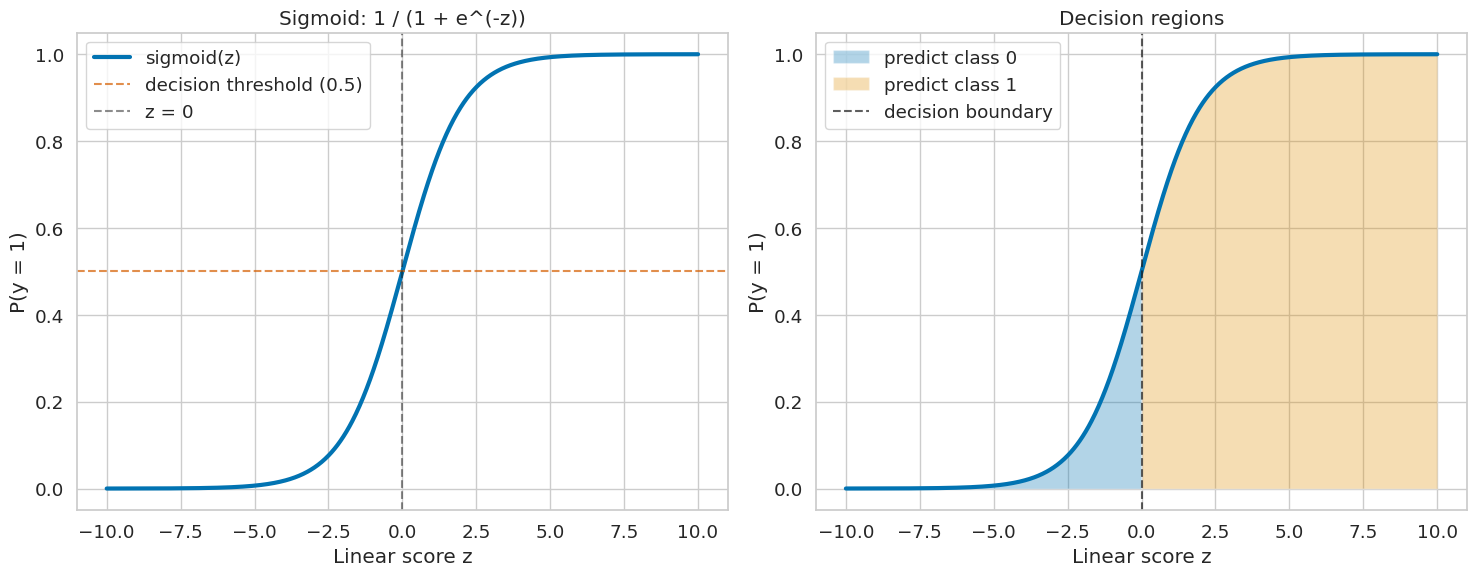

In [34]:
# Worked demo (free): the sigmoid and its decision regions.
def sigmoid(z):
    """Map any real number into a probability in (0, 1).

    Args:
        z: array-like or scalar linear score.
    Returns:
        The element-wise logistic transform 1 / (1 + e^(-z)).
    """
    return 1 / (1 + np.exp(-z))

zz = np.linspace(-10, 10, 1000)
ss = sigmoid(zz)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].plot(zz, ss, lw=3, label='sigmoid(z)')
axes[0].axhline(0.5, color='r', ls='--', alpha=0.7, label='decision threshold (0.5)')
axes[0].axvline(0, color='k', ls='--', alpha=0.5, label='z = 0')
axes[0].set_xlabel("Linear score z"); axes[0].set_ylabel("P(y = 1)")
axes[0].set_title("Sigmoid: 1 / (1 + e^(-z))"); axes[0].legend()

axes[1].plot(zz, ss, lw=3)
axes[1].fill_between(zz[zz < 0], ss[zz < 0], alpha=0.3, label='predict class 0')
axes[1].fill_between(zz[zz > 0], ss[zz > 0], alpha=0.3, label='predict class 1')
axes[1].axvline(0, color='k', ls='--', alpha=0.7, label='decision boundary')
axes[1].set_xlabel("Linear score z"); axes[1].set_ylabel("P(y = 1)")
axes[1].set_title("Decision regions"); axes[1].legend()
plt.tight_layout(); plt.show()

The left panel is the sigmoid curve; the right panel splits that same curve into its two decision
regions at `z = 0`. The curve is steep only for `z` roughly in `[-5, 5]` and flattens toward 0 or 1
outside that band, and the `P = 0.5` threshold lands at `z = 0`.

> **Note:** because the sigmoid's steep range sits at roughly `z` in `[-5, 5]`, a feature on a huge
> scale (body mass runs in the thousands of grams) forces the model to learn a small coefficient that
> rescales that feature down into the steep range. This is the key to the small-coefficient puzzle at
> the end of this question.


> **Predict, then check:** Gentoos are the larger species (you saw it in the scatter). Before fitting,
> predict:
>
> - The **sign** of the bill-length coefficient: positive (bigger bill, more likely Gentoo) or negative?
> - Roughly **how accurate** can bill + mass be at telling these two species apart?
>
> Record your guess below, then fit.


In [35]:
# Predict, then check (not graded). Record your guess as a string, then run the cells below.
predict_q4 = "The bill coefficent will be negative. It would 90% accurate, and they dont overlap much."   # e.g. "bill coefficient positive; accuracy near-perfect (~95%+); the clouds barely overlap"

**Goal:** build the binary problem (Adelie vs. Gentoo), fit a logistic model, and produce both
hard and soft predictions.

**Steps:**
1. `binary_mask` = rows whose species is in `['Adelie', 'Gentoo']` (`Series.isin(...)`).
2. `X_binary` = those rows' `bill_length_mm`, `body_mass_g`; `y_binary` = `(species == 'Gentoo')`
   as int (Gentoo = 1, Adelie = 0).
3. Split (`test_size=0.3, random_state=RANDOM_STATE`); fit
   `LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)`.
4. `y_pred_binary` = `.predict(...)` (hard labels); `y_proba_binary` = `.predict_proba(...)`
   (a 2-column array of probabilities).

Third time fitting, so only the new ops get a hint.


In [36]:
# binary_mask:      boolean Series selecting Adelie & Gentoo rows
# X_binary:         features (bill_length_mm, body_mass_g) for those rows
# y_binary:         int target, Gentoo = 1, Adelie = 0
# logistic_model:   a fitted LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
# y_pred_binary:    hard class predictions on the test set
# y_proba_binary:   (n_test, 2) array of class probabilities on the test set
# y_test_binary:    the test labels (kept for the self-check and confusion matrix)

binary_mask = None
X_binary = None
y_binary = None
logistic_model = None
y_pred_binary = None
y_proba_binary = None
y_test_binary = None

#YOUR CODE HERE
binary_mask = penguins['species'].isin(['Adelie', 'Gentoo'])
X_binary = penguins.loc[binary_mask, ['bill_length_mm', 'body_mass_g']]
y_binary = (penguins.loc[binary_mask, 'species'] == 'Gentoo').astype(int)

Xtr_binary, Xte_binary, ytr_binary, y_test_binary = train_test_split(
    X_binary, y_binary, test_size=0.3, random_state=RANDOM_STATE
)

logistic_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE).fit(Xtr_binary, ytr_binary)
y_pred_binary = logistic_model.predict(Xte_binary)
y_proba_binary = logistic_model.predict_proba(Xte_binary)


In [37]:
# Self-check (free): hard labels vs. soft probabilities.
if y_proba_binary is not None:
    print(f"Gentoo penguins in the binary set: {int(y_binary.sum())}")
    print(f"Bill-length coefficient: {logistic_model.coef_[0][0]:+.3f}\n")
    print("First 10 test penguins (P columns are [P(Adelie), P(Gentoo)]):")
    for i in range(min(10, len(y_proba_binary))):
        print(f"  pred={y_pred_binary[i]}  P(Adelie)={y_proba_binary[i,0]:.3f}  P(Gentoo)={y_proba_binary[i,1]:.3f}")
else:
    print("Fill in the logistic model above, then run this cell.")

Gentoo penguins in the binary set: 119
Bill-length coefficient: +0.842

First 10 test penguins (P columns are [P(Adelie), P(Gentoo)]):
  pred=1  P(Adelie)=0.000  P(Gentoo)=1.000
  pred=0  P(Adelie)=1.000  P(Gentoo)=0.000
  pred=0  P(Adelie)=1.000  P(Gentoo)=0.000
  pred=0  P(Adelie)=0.991  P(Gentoo)=0.009
  pred=0  P(Adelie)=0.999  P(Gentoo)=0.001
  pred=0  P(Adelie)=0.999  P(Gentoo)=0.001
  pred=1  P(Adelie)=0.181  P(Gentoo)=0.819
  pred=0  P(Adelie)=0.960  P(Gentoo)=0.040
  pred=0  P(Adelie)=0.943  P(Gentoo)=0.057
  pred=0  P(Adelie)=0.992  P(Gentoo)=0.008


In [38]:
# Visible sanity: probabilities are well-formed and the hard labels are the argmax of the soft probs.
# (1 of this question's 3 model points is this visible check; the other 2 are a hidden recompute.)
assert y_binary is not None, "Build the binary target y_binary."
assert set(np.unique(y_binary)) == {0, 1}, "y_binary should be 0/1 only (Gentoo=1, Adelie=0)."
assert y_proba_binary is not None and y_proba_binary.shape[1] == 2, "predict_proba should return 2 columns."
assert np.allclose(y_proba_binary.sum(axis=1), 1), "Each row of probabilities must sum to 1."
assert np.array_equal(np.asarray(y_pred_binary), np.argmax(y_proba_binary, axis=1)), \
    "y_pred_binary must equal the argmax of y_proba_binary."

### Logistic regression is the Q1 linear score, run through a sigmoid

You built `X @ coef + b` in Question 1. Logistic regression wraps that score in `sigmoid`. To show
it, compute `z` by hand, push it through `sigmoid`, and compare against `predict_proba`.


In [39]:
# Free demo, ungraded, reinforces the through-line.
if logistic_model is not None and y_proba_binary is not None:
    Xte_b_vals = X_binary.loc[y_test_binary.index].values
    z_by_hand = Xte_b_vals @ logistic_model.coef_[0] + logistic_model.intercept_[0]
    p_by_hand = sigmoid(z_by_hand)
    print("P(Gentoo) by hand   :", np.round(p_by_hand[:5], 4))
    print("predict_proba[:, 1] :", np.round(y_proba_binary[:5, 1], 4))
    print("Match all?", np.allclose(p_by_hand, y_proba_binary[:, 1]))
    print("\nThe two columns agree: logistic regression is the linear score from Q1, run through a sigmoid.")
else:
    print("Fit the logistic model first, then run this cell.")


P(Gentoo) by hand   : [9.999e-01 1.000e-04 0.000e+00 9.400e-03 7.000e-04]
predict_proba[:, 1] : [9.999e-01 1.000e-04 0.000e+00 9.400e-03 7.000e-04]
Match all? True

The two columns agree: logistic regression is the linear score from Q1, run through a sigmoid.


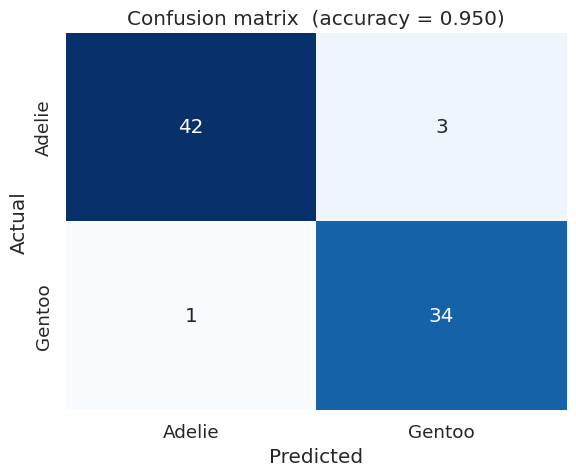

In [40]:
# Free visual: confusion matrix. (TP/TN on the diagonal; off-diagonal are the mistakes.)
if y_pred_binary is not None:
    cm = confusion_matrix(y_test_binary, y_pred_binary)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Adelie', 'Gentoo'], yticklabels=['Adelie', 'Gentoo'], ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(f"Confusion matrix  (accuracy = {accuracy_score(y_test_binary, y_pred_binary):.3f})")
    plt.tight_layout(); plt.show()
else:
    print("Run the logistic cell first.")

The confusion matrix has true species on the rows and the model's guess on the columns; the diagonal
holds the correct calls and the off-diagonal holds the mistakes. Almost everything sits on the
diagonal, and the few off-diagonal cells are the only penguins the model confused. For two species
that barely overlap in size, a straight-line boundary is enough. The next figure shows why that
boundary is a straight line.


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


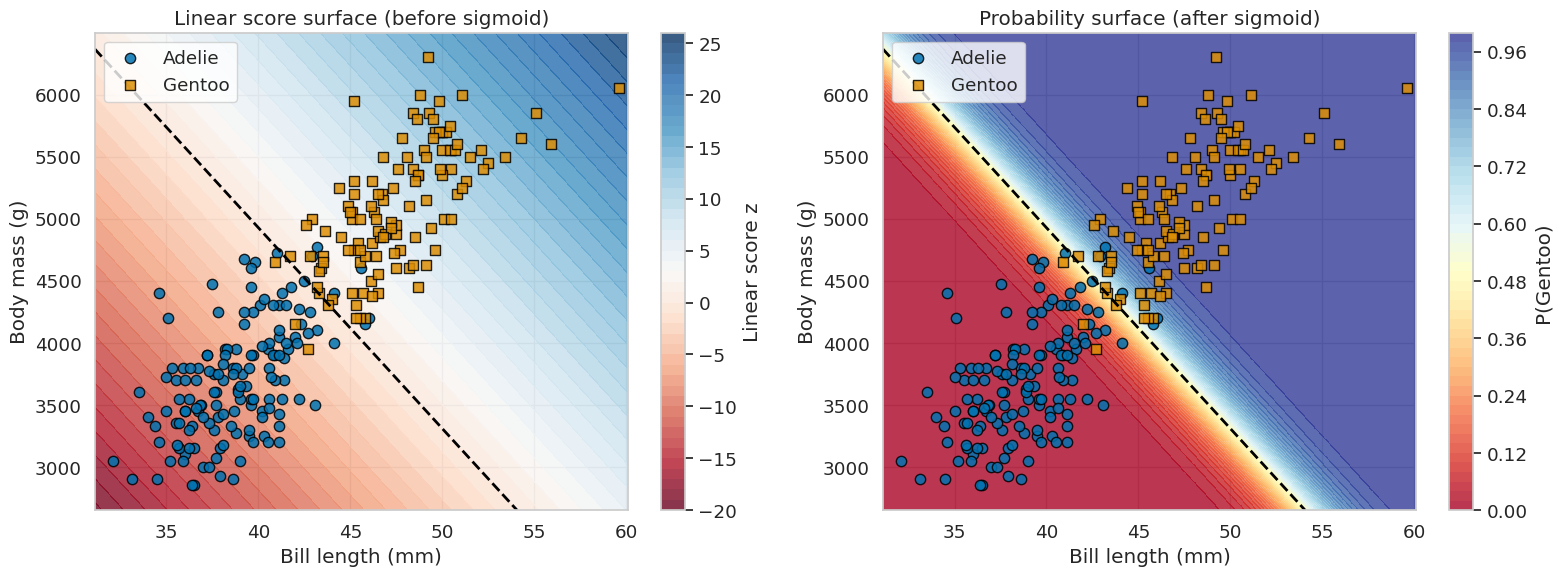

In [41]:
# Free visual: the linear surface and its sigmoid-squashed probability surface.
def decision_boundary_plots(model, Xb, yb):
    h = 0.5
    x_min, x_max = Xb['bill_length_mm'].min() - 1, Xb['bill_length_mm'].max() + 1
    y_min, y_max = Xb['body_mass_g'].min() - 200, Xb['body_mass_g'].max() + 200
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    mesh = np.c_[xx.ravel(), yy.ravel()]
    linear = model.coef_[0][0] * xx + model.coef_[0][1] * yy + model.intercept_[0]
    prob = model.predict_proba(mesh)[:, 1].reshape(xx.shape)
    return xx, yy, linear, prob

if logistic_model is not None:
    xx, yy, linear_pred, Z_prob = decision_boundary_plots(logistic_model, X_binary, y_binary)
    adelie = (y_binary == 0); gentoo = (y_binary == 1)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    c0 = axes[0].contourf(xx, yy, linear_pred, levels=50, alpha=0.8, cmap='RdBu')
    axes[0].contour(xx, yy, linear_pred, levels=[0], colors='black', linestyles='--', linewidths=2)
    axes[0].scatter(X_binary.loc[adelie, 'bill_length_mm'], X_binary.loc[adelie, 'body_mass_g'],
                    marker='o', s=55, alpha=0.85, label='Adelie', edgecolor='black')
    axes[0].scatter(X_binary.loc[gentoo, 'bill_length_mm'], X_binary.loc[gentoo, 'body_mass_g'],
                    marker='s', s=55, alpha=0.85, label='Gentoo', edgecolor='black')
    axes[0].set_xlabel("Bill length (mm)"); axes[0].set_ylabel("Body mass (g)")
    axes[0].set_title("Linear score surface (before sigmoid)"); axes[0].legend()
    plt.colorbar(c0, ax=axes[0], label="Linear score z")

    c1 = axes[1].contourf(xx, yy, Z_prob, levels=50, alpha=0.8, cmap='RdYlBu')
    axes[1].contour(xx, yy, Z_prob, levels=[0.5], colors='black', linestyles='--', linewidths=2)
    axes[1].scatter(X_binary.loc[adelie, 'bill_length_mm'], X_binary.loc[adelie, 'body_mass_g'],
                    marker='o', s=55, alpha=0.85, label='Adelie', edgecolor='black')
    axes[1].scatter(X_binary.loc[gentoo, 'bill_length_mm'], X_binary.loc[gentoo, 'body_mass_g'],
                    marker='s', s=55, alpha=0.85, label='Gentoo', edgecolor='black')
    axes[1].set_xlabel("Bill length (mm)"); axes[1].set_ylabel("Body mass (g)")
    axes[1].set_title("Probability surface (after sigmoid)"); axes[1].legend()
    plt.colorbar(c1, ax=axes[1], label="P(Gentoo)")
    plt.tight_layout(); plt.show()
else:
    print("Fit the logistic model first, then run this cell.")


The left panel shows the linear score surface `z`, and the right shows the sigmoid-squashed
probability surface `P(Gentoo)`; circles are Adelie, squares are Gentoo, and the dashed line is the
decision boundary. The boundary is a straight line in both panels: the sigmoid bends the colors
(turning scores into probabilities) but never bends the boundary itself.

That straight line is the "linear" in logistic regression, and also its limitation. The bill-length
coefficient came out positive (bigger penguin, more likely Gentoo), as the EDA suggested, but a
single line can't wrap around interleaved classes. Later models fix that.


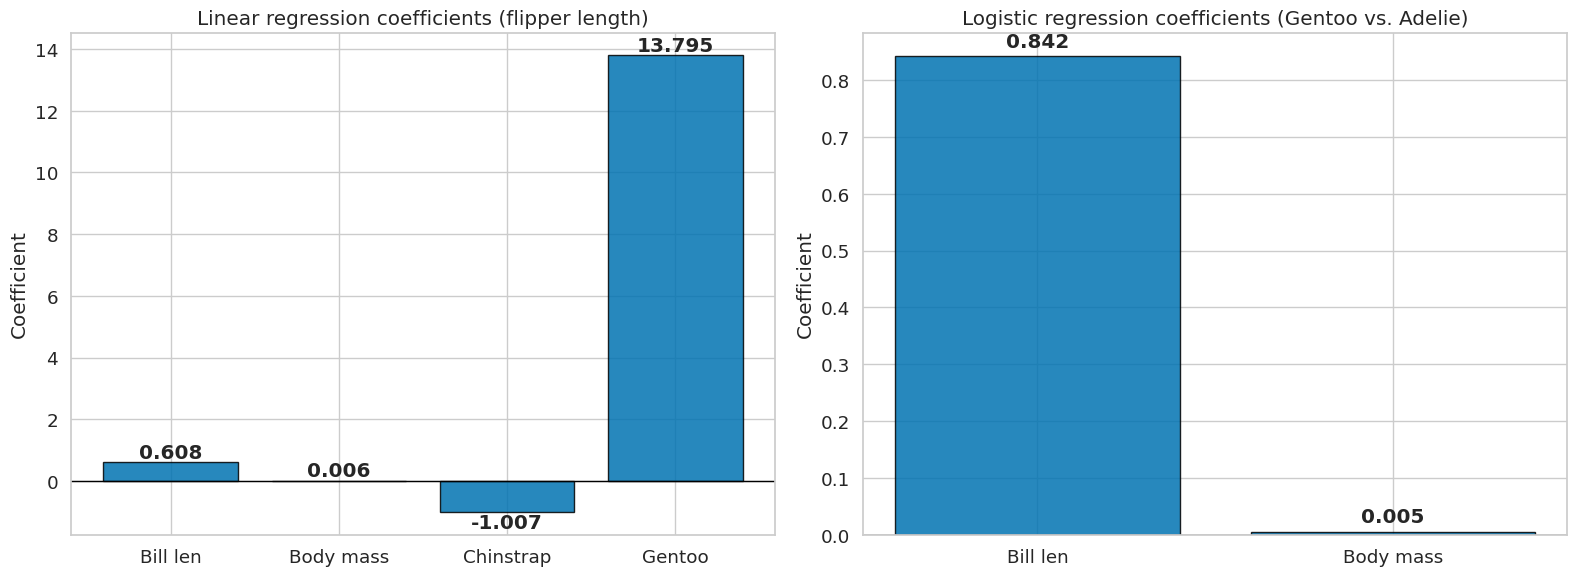

In [42]:
# Free visual: coefficient bar charts for both models.
def plot_coefficients(ax, coefs, names, title):
    bars = ax.bar(names, coefs, alpha=0.85, edgecolor='black')
    ax.axhline(0, color='black', lw=1)
    ax.set_title(title); ax.set_ylabel("Coefficient")
    for bar, c in zip(bars, coefs):
        hgt = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, hgt + (0.01 if hgt >= 0 else -0.05),
                f"{c:.3f}", ha='center', va='bottom' if hgt >= 0 else 'top', fontweight='bold')

if model_species is not None and logistic_model is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    plot_coefficients(axes[0], model_species.coef_,
                      ['Bill len', 'Body mass', 'Chinstrap', 'Gentoo'],
                      "Linear regression coefficients (flipper length)")
    plot_coefficients(axes[1], logistic_model.coef_[0],
                      ['Bill len', 'Body mass'],
                      "Logistic regression coefficients (Gentoo vs. Adelie)")
    plt.tight_layout(); plt.show()
else:
    print("Run the earlier model cells first.")

The two bar charts show the fitted coefficients side by side: the flipper-length regression on the
left and the Gentoo-vs-Adelie logistic model on the right. The logistic `body_mass` bar is tiny next
to `bill_length`, even though mass plainly helps tell the species apart.

That gap is about scale, not importance: coefficient magnitude is tangled up with feature scale (mass
is in thousands of grams). The next graded question asks you to resolve it.


### Reasoning (graded, 1 pt)

`body_mass`'s logistic coefficient (~0.005) is roughly **160x smaller** than `bill_length`'s (~0.84).

Write your answer into the `coef_reasoning` string below, covering **both** parts:

**(a)** Does that tiny coefficient mean body mass barely matters? Explain using the **range** of each
feature (bill ~35-60 mm vs. mass ~2700-6300 g). *(Hint: think about coefficient x typical value, and
the sigmoid insight from earlier in this question.)*

**(b)** Was your earlier prediction of the bill-length coefficient's **sign** correct, and why does
that sign make biological sense?

In [44]:
# coef_reasoning: your written answer to parts (a) and (b), as a multi-line string
coef_reasoning = """a.) No, a tiny coefficent doesn't mean body mass barely matters. The reason why
it does matter is becasue weaight has a far greater range and numerical value. Evene when multuiplying a small number,
it will cause a large diffrenece between numbers this great.

b.) My ealier prediciton of the coefficent's sign was incorrect, and the correct sign does make sense.
It is somewhat small compared to the typical values of the bill so while on average, the bill length of
the Gendoo is slightly larger than other species. This makes biological sense as there shouldn't
be much difference between the two species as they are still both penguins.
"""

# YOUR CODE HERE


In [45]:
# Self-check (free, NOT graded): keyword coverage for your coefficient answer.
# This only echoes which keywords it found; word choice is not what earns the points.
if coef_reasoning.strip():
    _t = coef_reasoning.lower()
    print("Word count:", len(coef_reasoning.split()), "(aim for >= 25 across BOTH parts)")
    print("  uses range/scale (a)  :", any(w in _t for w in [
        "range", "scale", "magnitude", "thousands", "units", "grams", "gram",
        "mm", "millimeter", "typical value", "feature value", "span", "spans"]))
    print("  addresses the sign (b):", any(w in _t for w in [
        "positive", "sign", "greater than zero", "above zero", "more than zero", "+", ">0", "> 0"]))
    print("All True means your answer touches each rubric area; the grader still reads it for correctness.")
else:
    print("Write coef_reasoning above, then run this cell to see your keyword coverage.")


Word count: 109 (aim for >= 25 across BOTH parts)
  uses range/scale (a)  : True
  addresses the sign (b): True
All True means your answer touches each rubric area; the grader still reads it for correctness.


In [46]:
_c = coef_reasoning.lower()
# MANUAL RUBRIC (graded by hand on CONTENT): (a) small coefficient x large range => comparable
#   contribution (reject "it barely matters"); (b) correctly reconciles the bill-length
#   coefficient's (positive) sign. The keyword asserts below are PRESENCE HINTS only; they are
#   intentionally wide so a correctly-reasoned answer is never rejected on word choice. They do not
#   judge whether the reasoning is right; the human grader does that.
assert isinstance(coef_reasoning, str), "coef_reasoning should be a string."
assert len(coef_reasoning.split()) >= 25, "Write a substantive answer to BOTH (a) and (b)."
assert any(w in _c for w in [
    "range", "scale", "magnitude", "thousands", "units", "grams", "gram",
    "mm", "millimeter", "typical value", "feature value", "span", "spans",
]), "Use the feature's range/scale/units in (a)."
assert any(w in _c for w in [
    "positive", "sign", "greater than zero", "above zero", "more than zero",
    "+", ">0", "> 0",
]), "Address the coefficient's sign in (b)."


> **Note, the reveal (after you've committed):** a large coefficient does not by itself mean an
> important feature; scale matters. A feature with a small coefficient can still be decisive if it
> ranges over thousands of units, and body mass is one such feature. The coefficient is multiplied by
> the feature value, so a tiny weight on a huge number can still move the linear score a lot. The
> sign is the interpretable part: positive means "more of this, more Gentoo." Later models (like
> decision trees) measure importance in ways that don't tangle it up with feature scale.

> **Key points:**
> - Logistic regression is the `X @ coef + b` score squashed by a sigmoid, then thresholded at 0.5.
> - It outputs **probabilities** (`predict_proba`), not just labels: confidence you can act on.
> - A coefficient's **sign** is interpretable; its **magnitude** is entangled with the feature's scale.

---


## Question 5: The Challenge: beat a baseline you can't game  (1 + 2 + 3 = 6 pts)

New target: **`body_mass_g`**, the measurement biologists most want from a photo. A lazy baseline
(the three numeric measurements) gets RMSE around 375 g. Your job: get under 305 g by choosing
features.

> **Warning, one signal is not enough.** We measured every single-column add-on on the grader's
> hidden split: the best one (`species`) only reaches about 320 g, still short of the gate. Clearing
> it takes two strong signals working together, and not just any two. Read the menu below before you
> commit to a design, because the weak pairings fall just short.

> **Warning, you can't game this one.** The grader refits your feature set on a fresh
> train/test split it picks (`ALT_RANDOM_STATE`) and ignores whatever RMSE you print. A lucky split
> won't save you, and typing a number does nothing.

> **Test guidance:** Public tests carry most autograded points overall, so run this task's public test before submitting. Its smaller hidden check recomputes the result from the required objects, so derive values in code and preserve the requested labels, split, metric, and seed.

BASELINE (3 numeric features): RMSE = 375.3 g
Target to clear: RMSE < 305 g on the grader's fresh split.



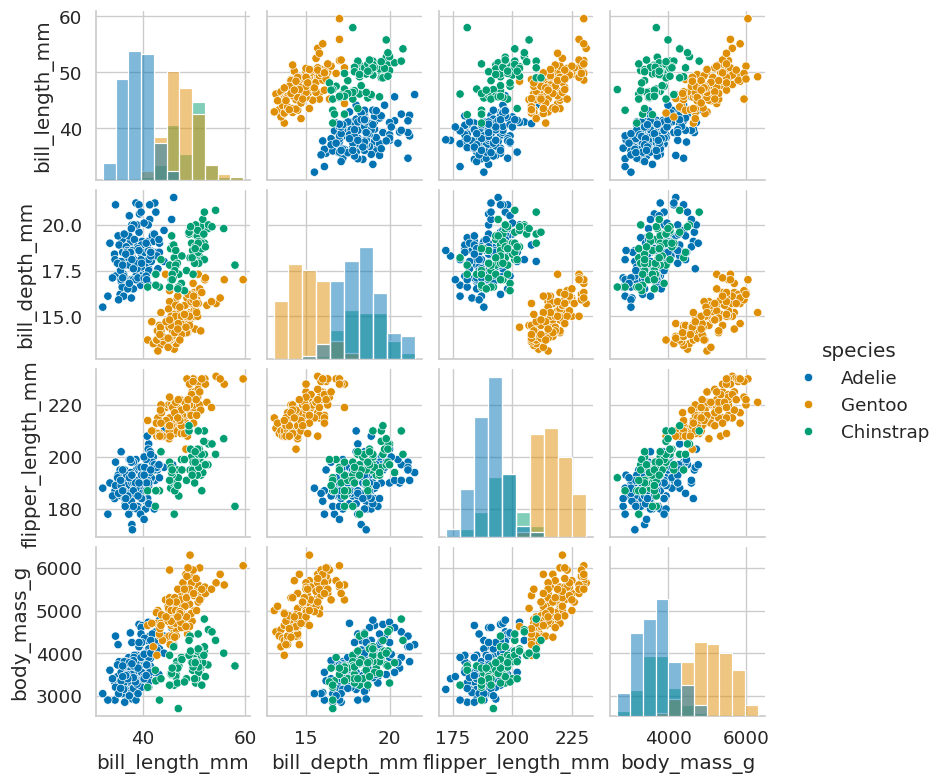

In [47]:
# Baseline + a feature-selection aid. (Free.)
y_mass = penguins['body_mass_g']
base_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(penguins[base_cols], y_mass,
                                              test_size=0.3, random_state=RANDOM_STATE)
baseline_model = LinearRegression().fit(Xb_tr, yb_tr)
baseline_rmse = np.sqrt(mean_squared_error(yb_te, baseline_model.predict(Xb_te)))
print(f"BASELINE (3 numeric features): RMSE = {baseline_rmse:.1f} g")
print(f"Target to clear: RMSE < 305 g on the grader's fresh split.\n")

# Which measurements track body mass? Which categories separate the clouds? Your answer is in here.
sns.pairplot(penguins[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'species']],
             hue='species', diag_kind='hist', height=2)
plt.show()

Each panel plots one pair of measurements against another, colored by species, with each feature's
distribution along the diagonal. `flipper_length_mm` rises tightly with `body_mass_g`, and the
species sit in distinct bands on almost every panel. Treat this as your scouting report for the
Challenge: the strongest numeric predictor and the most separating categorical column are both
visible here, so use it to choose features.


**The menu of legitimate moves.** You may:

- add or drop **numeric** features,
- one-hot encode a **categorical** column (`species`, `sex`, or `island`), the Question-3 skill,
- engineer **polynomial / interaction** terms.

> **Warning, pick your two signals carefully; not every pair clears the gate.** Combining two
> *weak* signals is not enough: pairs built around `island`, and a *single* squared term added to one
> categorical, all land around 319-335 g, above the gate. What clears it is combining the **two most
> informative signals**. Your scouting report (the pairplot) shows which categorical separates the
> mass clouds most cleanly and which numeric tracks mass tightest; the strongest categorical *paired
> with* the next-most-informative categorical is the reliable route. (A *full* degree-2 polynomial
> expansion of the numeric features plus that second categorical also clears it, but a lone squared
> term does not.) Exact numbers are revealed after you commit, in the Reflect box at the end.

> **Predict, then check:** which single categorical column do you bet helps most for predicting
> mass: `species`, `sex`, or `island`? And which *pair* do you expect to clear the gate? Record your
> guess below; you'll check it against the measured numbers after the gate.

**The gate (stated plainly):** RMSE **< 305 g** on the grader's fresh `ALT_RANDOM_STATE` split,
reachable by combining the two most informative signals (the weak pairings above fall short).

In [48]:
# Predict, then check (not graded). Record your guess as a string, then build your model below.
predict_q5 = "sex helps a lot; species helps less; the island helps more than species."   # e.g. "sex helps most; species also helps; island barely matters"

**Goal:** choose a feature set and fit a model that clears the gate. You decide the features,
any valid combination. The grader recomputes RMSE on its own split, so just report your design and a
fitted model.

In Question 3 you concatenated **one** dummy block. Here you'll likely want **two**. The skeleton below
shows the *shape* of a two-block design matrix on a deliberately-different pair (`species` + `island`)
so you can adapt it. It is **not** the winning pair, so copying it verbatim will miss the gate:

```python
# SKELETON to adapt (species + island is a weak pair on purpose; swap in your own choice):
demo_feats = penguins[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']].copy()
demo_feats = pd.concat([
    demo_feats,
    pd.get_dummies(penguins['species'], prefix='species', drop_first=True),
    pd.get_dummies(penguins['island'],  prefix='island',  drop_first=True),   # change this block
], axis=1)
```

**Steps:**
1. `challenge_features` = your design matrix, **aligned to all 333 rows** (so the grader can re-split
   it). Numeric columns plus the one-hot dummy blocks you choose.
2. `challenge_model` = a `LinearRegression` fit on a `RANDOM_STATE` split predicting `y_mass`.
3. `challenge_rmse` = your own test-set RMSE (self-check only, *not* your grade).

You've built every piece of this already. Combine them.

In [49]:
# challenge_features: DataFrame, your design matrix aligned to ALL rows of penguins
# challenge_model:    a fitted LinearRegression predicting body_mass_g
# challenge_rmse:     float, your own test-set RMSE (self-check only; the grader recomputes its own)

challenge_features = None
challenge_model = None
challenge_rmse = None

#YOUR CODE HERE
numeric_features = penguins[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']].copy()
species_dummies_challenge = pd.get_dummies(penguins['species'], prefix='species', drop_first=True)
sex_dummies_challenge = pd.get_dummies(penguins['sex'], prefix='sex', drop_first=True)

challenge_features = pd.concat([
    numeric_features,
    species_dummies_challenge,
    sex_dummies_challenge
], axis=1)

y_mass = penguins['body_mass_g']

Xtr_challenge, Xte_challenge, ytr_challenge, yte_challenge = train_test_split(
    challenge_features, y_mass, test_size=0.3, random_state=RANDOM_STATE
)
challenge_model = LinearRegression().fit(Xtr_challenge, ytr_challenge)
preds_challenge = challenge_model.predict(Xte_challenge)
challenge_rmse = np.sqrt(mean_squared_error(yte_challenge, preds_challenge))


In [50]:
# Self-check (free): the grader recomputes RMSE on its OWN hidden split, so this is only a preview.
target_rmse = 305  # matches the real full-credit gate (see Question 5 policy)
if challenge_rmse is not None:
    print(f"Your RMSE: {challenge_rmse:.1f} g   |   Baseline: {baseline_rmse:.1f} g")
    if challenge_rmse < target_rmse:
        print(f"On track! Under {target_rmse} g on the split you can see. "
              f"The grader re-checks on its own (slightly different) split, so leave a little margin.")
    else:
        print(f"Not yet: reduce RMSE by {challenge_rmse - target_rmse:.1f} g more "
              f"(combine your strongest TWO signals; weak pairs around 'island' tend to fall short).")
else:
    print("Build your challenge model above, then run this cell.")

Your RMSE: 279.1 g   |   Baseline: 375.3 g
On track! Under 305 g on the split you can see. The grader re-checks on its own (slightly different) split, so leave a little margin.


In [51]:
# Visible sanity: the model exists, the matrix aligns to all rows, and it beats the baseline on the
# VISIBLE split (recomputed; we do not trust challenge_rmse).
assert challenge_model is not None and challenge_features is not None, "Build challenge_features and challenge_model."
assert challenge_features.shape[0] == len(penguins), \
    f"Feature matrix must align to all {len(penguins)} rows, got {challenge_features.shape[0]}."
assert challenge_features.shape[1] >= 4, "Use at least 4 features."
assert 'body_mass_g' not in challenge_features.columns, "Do not put the target body_mass_g in challenge_features (that is leakage)."
_ym = penguins['body_mass_g']
_Xtr, _Xte, _ytr, _yte = train_test_split(challenge_features, _ym, test_size=0.3, random_state=RANDOM_STATE)
_rmse_vis = np.sqrt(mean_squared_error(_yte, LinearRegression().fit(_Xtr, _ytr).predict(_Xte)))
_bcols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']
_Btr, _Bte, _bytr, _byte = train_test_split(penguins[_bcols], _ym, test_size=0.3, random_state=RANDOM_STATE)
_base_rmse = np.sqrt(mean_squared_error(_byte, LinearRegression().fit(_Btr, _bytr).predict(_Bte)))
assert _rmse_vis < _base_rmse, f"Must beat the baseline on the visible split (you: {_rmse_vis:.1f}, baseline: {_base_rmse:.1f})."

> **Reflect, and the reveal (after you've committed):** did your predicted best categorical column
> win? Did your pair clear the gate? In one sentence: why does `sex` carry information about body mass
> that the size measurements alone don't?
>
> *What we measured on the grader's held-out split:* the best **single** add-on is `species` at
> ~320 g, above the gate. The reliable clearer is **species + sex** at ~291 g. A **full degree-2
> polynomial expansion of the numeric features + sex** also clears it at ~300 g. The tempting-but-weak
> pairings fall just short: **species + island** ~319 g, **sex + island** ~319 g, and a **single
> squared term + sex** ~335 g. That is why the gate rewards combining the *two most informative*
> signals, not just any two moves.

> **Playground (optional, not graded):** the cell below sweeps a polynomial degree and plots the
> held-out RMSE so you can *see* the bias-variance tradeoff. It touches only throwaway `_`-named
> variables, so nothing here can change your grade. If `ipywidgets` is installed you get a slider;
> otherwise you get the same sweep as a static plot.
>
> Things to try and leave a note about in a comment:
> - **(a)** Where does the curve bottom out, and where does adding degree start to *hurt* (overfit)?
> - **(b)** Swap `_play_target` to `'bill_depth_mm'`: does the best degree change?
> - **(c)** Standardize the features with `StandardScaler` and re-examine the logistic coefficients now
>   that they're on a comparable scale, the proper resolution of the "tiny coefficient" puzzle.

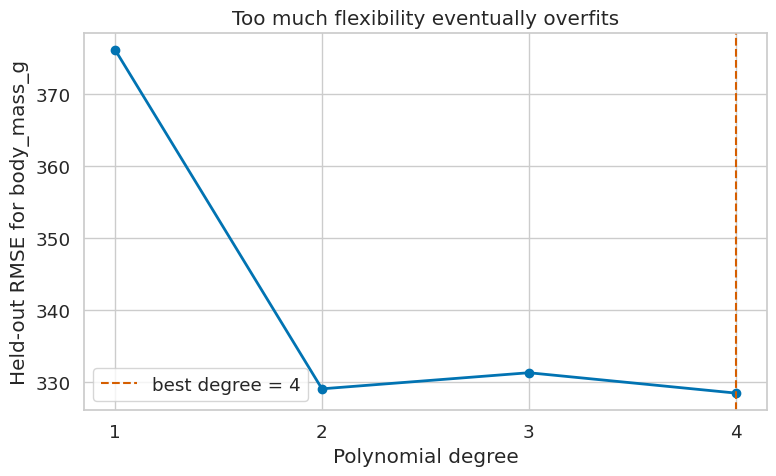

In [52]:
# Playground, ungraded, read-only on throwaway _-named variables. Safe to edit or skip.
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

_play_target = 'body_mass_g'          # try 'bill_depth_mm' for part (b)
_play_num = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']

def _poly_rmse(_degree):
    """Held-out RMSE of a polynomial linear model at a given degree (throwaway helper)."""
    _Xp = penguins[_play_num]
    _yp = penguins[_play_target]
    _Xtr, _Xte, _ytr, _yte = train_test_split(_Xp, _yp, test_size=0.3, random_state=ALT_RANDOM_STATE)
    _pipe = make_pipeline(PolynomialFeatures(degree=_degree, include_bias=False), LinearRegression())
    _pipe.fit(_Xtr, _ytr)
    return float(np.sqrt(mean_squared_error(_yte, _pipe.predict(_Xte))))

def _show_sweep(_max_degree=4):
    _degrees = list(range(1, _max_degree + 1))
    _rmses = [_poly_rmse(_d) for _d in _degrees]
    _fig, _ax = plt.subplots(figsize=(8, 5))
    _ax.plot(_degrees, _rmses, marker='o', lw=2)
    _best = _degrees[int(np.argmin(_rmses))]
    _ax.axvline(_best, color='r', ls='--', label=f'best degree = {_best}')
    _ax.set_xlabel("Polynomial degree"); _ax.set_ylabel(f"Held-out RMSE for {_play_target}")
    _ax.set_title("Too much flexibility eventually overfits"); _ax.set_xticks(_degrees); _ax.legend()
    plt.tight_layout(); plt.show()

# Default to the STATIC sweep (a bare "Run All" before submitting can't stall the kernel here).
# Set _INTERACTIVE = True yourself if you want the slider while exploring live.
_INTERACTIVE = False
try:
    if _INTERACTIVE:
        from ipywidgets import interact, IntSlider
        interact(_show_sweep, _max_degree=IntSlider(min=2, max=6, value=4, description='max degree'))
    else:
        _show_sweep(4)
except Exception:
    # Headless / Gradescope / no ipywidgets: show the static sweep instead.
    _show_sweep(4)

# Leave your findings here:
# (a) ...
# (b) ...

---

## Wrap-up

You opened by predicting a flipper in a handful of lines. You close having computed predictions by
hand, implemented `RMSE` and `R^2` from scratch and matched sklearn to the decimal, decided that
species carries information beyond size and justified it from the coefficients, built and interpreted
a logistic classifier, and selected a feature set that beat a baseline on a split you never saw. That
covers the whole supervised loop and the objectives we set out at the start.

> **Reflect, carry these forward:**
> - When did adding a feature help, and when might more features start to *hurt*?
> - The logistic boundary was a straight line. What kind of data would defeat it?
> - Your Challenge model beats the baseline, but how would you know if it's *overfitting*? (The
>   playground's degree sweep is a first taste.)

Next up, **2d: Classification Algorithms**, where we go past straight-line boundaries.
